In [1]:
!pip install textblob yfinance pandas matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
sp500 = yf.download("^GSPC", start="2019-01-01", end="2026-01-01")
sp500 = sp500[['Close']].reset_index()
sp500.columns = ['Date', 'SP500']
sp500['Date'] = pd.to_datetime(sp500['Date'])

print("✅ S&P 500 loaded!")
print(sp500.tail())

[*********************100%***********************]  1 of 1 completed

✅ S&P 500 loaded!
           Date        SP500
1755 2025-12-24  6932.049805
1756 2025-12-26  6929.939941
1757 2025-12-29  6905.740234
1758 2025-12-30  6896.240234
1759 2025-12-31  6845.500000


In [4]:
economic_data = {
    'Date': [
        '2019-01-01', '2019-04-01', '2019-07-01', '2019-10-01',
        '2020-01-01', '2020-04-01', '2020-07-01', '2020-10-01',
        '2021-01-01', '2021-04-01', '2021-07-01', '2021-10-01',
        '2022-01-01', '2022-04-01', '2022-07-01', '2022-10-01',
        '2023-01-01', '2023-04-01', '2023-07-01', '2023-10-01',
        '2024-01-01', '2024-04-01', '2024-07-01', '2024-10-01',
        '2025-01-01', '2025-04-01',
        '2026-01-01'
    ],
    'Unemployment': [
        4.0, 3.6, 3.7, 3.5,
        3.6, 14.7, 10.2, 6.9,
        6.4, 6.0, 5.4, 4.6,
        4.0, 3.6, 3.5, 3.7,
        3.4, 3.4, 3.5, 3.8,
        3.7, 3.9, 4.1, 4.2,
        4.1, 4.2,
        4.5
    ],
    'Inflation': [
        1.6, 1.8, 1.8, 2.1,
        2.3, 0.3, 1.0, 1.2,
        1.4, 4.2, 5.4, 6.2,
        7.5, 8.3, 8.5, 7.7,
        6.4, 4.9, 3.2, 3.7,
        3.1, 3.4, 2.9, 2.7,
        2.8, 2.6,
        2.4
    ],
    'GDP_Growth': [
        2.1, 2.0, 2.1, 2.4,
        -5.0, -31.4, 33.8, 4.5,
        6.3, 6.7, 2.3, 6.9,
        -1.6, -0.6, 3.2, 2.6,
        2.2, 2.1, 4.9, 3.3,
        1.6, 2.8, 3.0, 2.5,
        2.3, 1.8,
        1.2
    ],
    'Recession': [
        0, 0, 0, 0,
        0, 1, 1, 0,
        0, 0, 0, 0,
        0, 0, 0, 0,
        0, 0, 0, 0,
        0, 0, 0, 0,
        0, 0,
        0
    ]
}

df_econ = pd.DataFrame(economic_data)
df_econ['Date'] = pd.to_datetime(df_econ['Date'])

print("✅ Economic data loaded!")
print(df_econ.tail())

✅ Economic data loaded!
         Date  Unemployment  Inflation  GDP_Growth  Recession
22 2024-07-01           4.1        2.9         3.0          0
23 2024-10-01           4.2        2.7         2.5          0
24 2025-01-01           4.1        2.8         2.3          0
25 2025-04-01           4.2        2.6         1.8          0
26 2026-01-01           4.5        2.4         1.2          0


In [5]:
def calculate_warning_score(row):
    score = 0

    # Unemployment signal
    if row['Unemployment'] > 6:
        score += 30
    elif row['Unemployment'] > 4.5:
        score += 15

    # Inflation signal
    if row['Inflation'] > 7:
        score += 30
    elif row['Inflation'] > 4:
        score += 15

    # GDP signal
    if row['GDP_Growth'] < 0:
        score += 40
    elif row['GDP_Growth'] < 2:
        score += 10

    return score

def risk_level(score):
    if score >= 60:
        return '🔴 HIGH RISK'
    elif score >= 30:
        return '🟡 MEDIUM RISK'
    else:
        return '🟢 LOW RISK'

df_econ['Warning_Score'] = df_econ.apply(
    calculate_warning_score, axis=1)
df_econ['Risk_Level'] = df_econ['Warning_Score'].apply(risk_level)

print("\n📊 Recession Warning Scores:")
print(df_econ[['Date', 'Unemployment',
               'Inflation', 'GDP_Growth',
               'Warning_Score',
               'Risk_Level']].to_string())


📊 Recession Warning Scores:
         Date  Unemployment  Inflation  GDP_Growth  Warning_Score     Risk_Level
0  2019-01-01           4.0        1.6         2.1              0     🟢 LOW RISK
1  2019-04-01           3.6        1.8         2.0              0     🟢 LOW RISK
2  2019-07-01           3.7        1.8         2.1              0     🟢 LOW RISK
3  2019-10-01           3.5        2.1         2.4              0     🟢 LOW RISK
4  2020-01-01           3.6        2.3        -5.0             40  🟡 MEDIUM RISK
5  2020-04-01          14.7        0.3       -31.4             70    🔴 HIGH RISK
6  2020-07-01          10.2        1.0        33.8             30  🟡 MEDIUM RISK
7  2020-10-01           6.9        1.2         4.5             30  🟡 MEDIUM RISK
8  2021-01-01           6.4        1.4         6.3             30  🟡 MEDIUM RISK
9  2021-04-01           6.0        4.2         6.7             30  🟡 MEDIUM RISK
10 2021-07-01           5.4        5.4         2.3             30  🟡 MEDIUM RISK

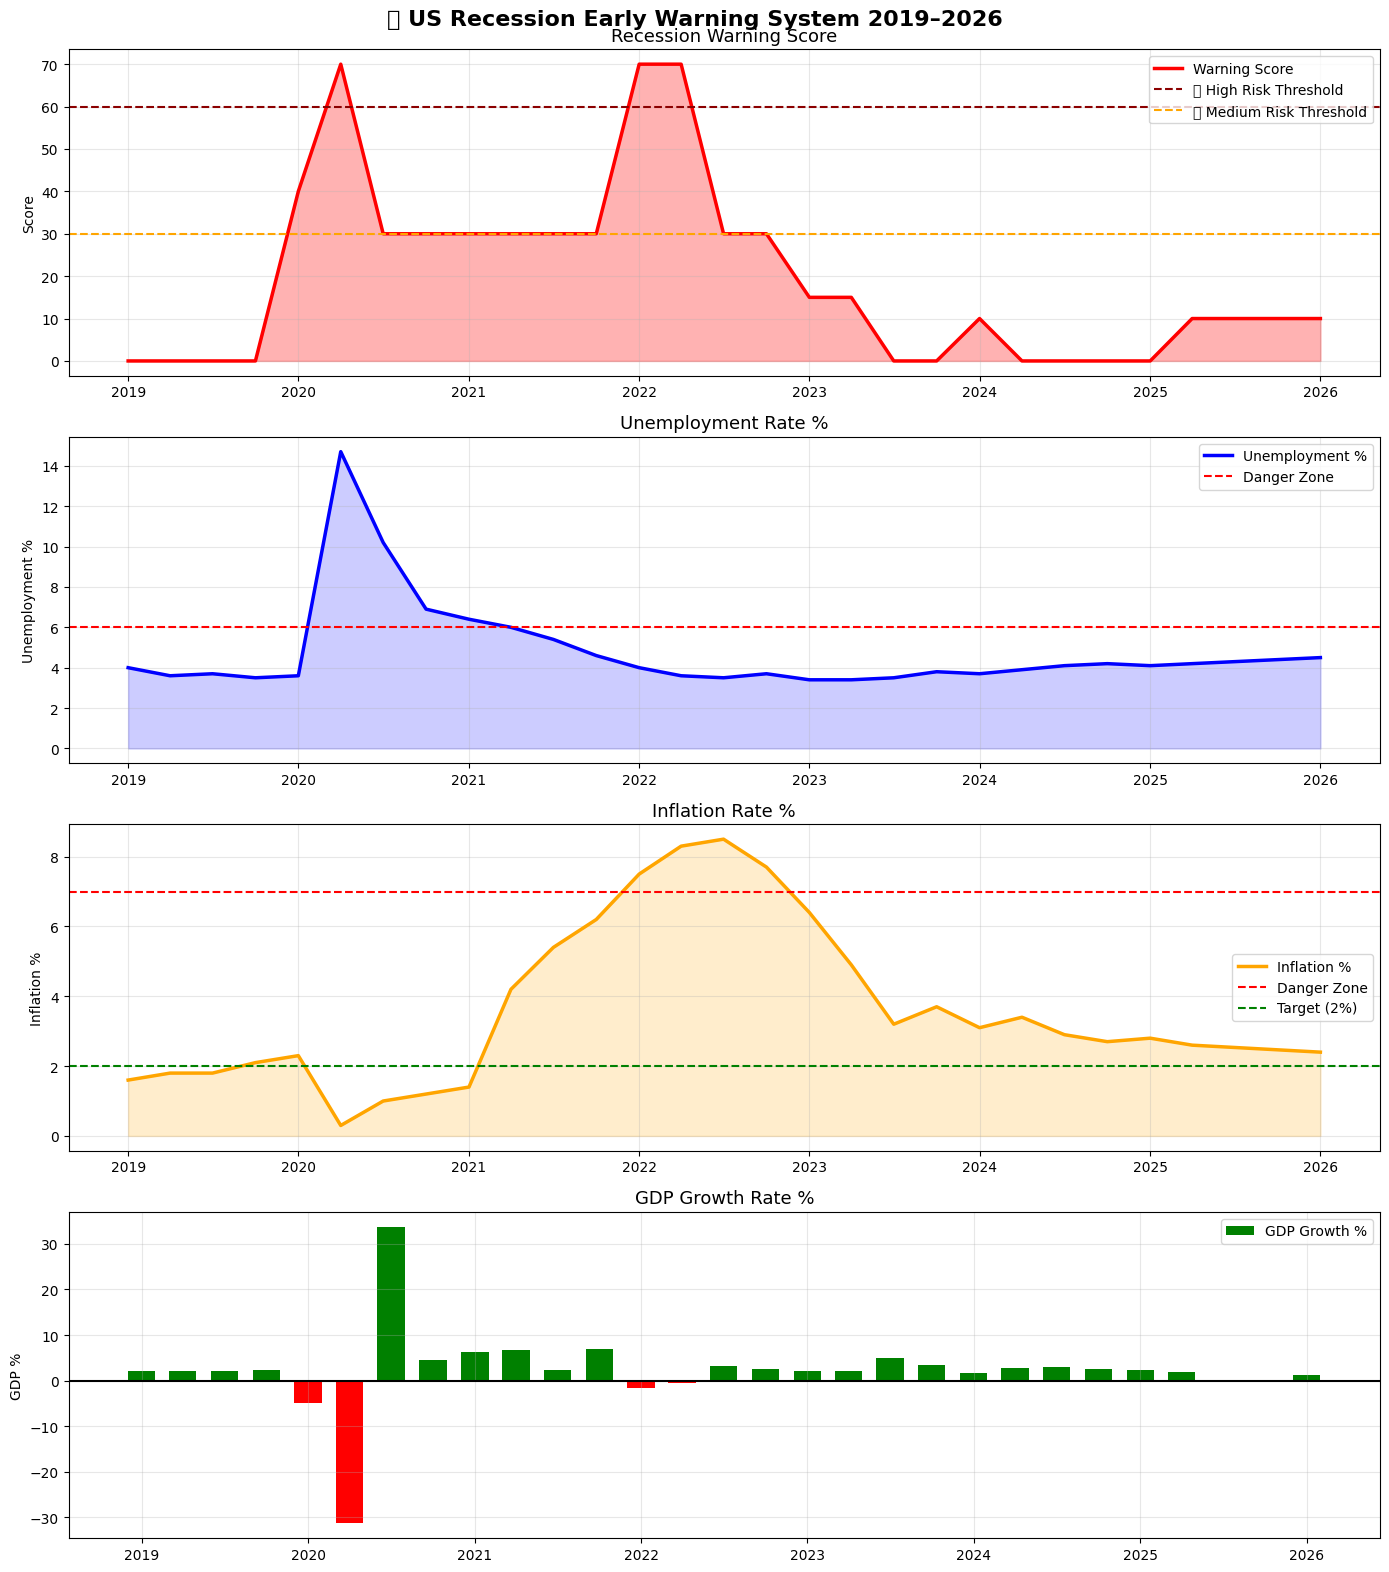

✅ Dashboard saved!


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle('🚨 US Recession Early Warning System 2019–2026',
             fontsize=16, fontweight='bold')

# Plot 1 — Warning Score
axes[0].fill_between(df_econ['Date'],
                     df_econ['Warning_Score'],
                     color='red', alpha=0.3)
axes[0].plot(df_econ['Date'],
             df_econ['Warning_Score'],
             color='red', linewidth=2.5,
             label='Warning Score')
axes[0].axhline(y=60, color='darkred',
                linestyle='--',
                label='🔴 High Risk Threshold')
axes[0].axhline(y=30, color='orange',
                linestyle='--',
                label='🟡 Medium Risk Threshold')
axes[0].set_title('Recession Warning Score', fontsize=13)
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Unemployment
axes[1].plot(df_econ['Date'],
             df_econ['Unemployment'],
             color='blue', linewidth=2.5,
             label='Unemployment %')
axes[1].axhline(y=6, color='red',
                linestyle='--',
                label='Danger Zone')
axes[1].fill_between(df_econ['Date'],
                     df_econ['Unemployment'],
                     color='blue', alpha=0.2)
axes[1].set_title('Unemployment Rate %', fontsize=13)
axes[1].set_ylabel('Unemployment %')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — Inflation
axes[2].plot(df_econ['Date'],
             df_econ['Inflation'],
             color='orange', linewidth=2.5,
             label='Inflation %')
axes[2].axhline(y=7, color='red',
                linestyle='--',
                label='Danger Zone')
axes[2].axhline(y=2, color='green',
                linestyle='--',
                label='Target (2%)')
axes[2].fill_between(df_econ['Date'],
                     df_econ['Inflation'],
                     color='orange', alpha=0.2)
axes[2].set_title('Inflation Rate %', fontsize=13)
axes[2].set_ylabel('Inflation %')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4 — GDP Growth
colors = ['red' if x < 0 else 'green'
          for x in df_econ['GDP_Growth']]
axes[3].bar(df_econ['Date'],
            df_econ['GDP_Growth'],
            color=colors, width=60,
            label='GDP Growth %')
axes[3].axhline(y=0, color='black', linewidth=1.5)
axes[3].set_title('GDP Growth Rate %', fontsize=13)
axes[3].set_ylabel('GDP %')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('recession_warning_2026.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved!")

In [8]:
features = ['Unemployment', 'Inflation',
            'GDP_Growth', 'Warning_Score']
X = df_econ[features]
y = df_econ['Recession']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(
    n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ AI Model trained successfully!")
print("\nModel Performance:")
y_pred = model.predict(X_test)

# Fixed — added labels parameter
print(classification_report(
    y_test, y_pred,
    labels=[0, 1],
    target_names=['Stable', 'Recession'],
    zero_division=0))

✅ AI Model trained successfully!

Model Performance:
              precision    recall  f1-score   support

      Stable       1.00      1.00      1.00         6
   Recession       0.00      0.00      0.00         0

    accuracy                           1.00         6
   macro avg       0.50      0.50      0.50         6
weighted avg       1.00      1.00      1.00         6



In [9]:
# Current 2026 data
current_2026 = pd.DataFrame({
    'Unemployment': [4.5],
    'Inflation': [2.4],
    'GDP_Growth': [1.2],
    'Warning_Score': [10]
})

prediction = model.predict(current_2026)
probability = model.predict_proba(current_2026)

print("=" * 50)
print("🌍 US ECONOMY 2026 — AI PREDICTION")
print("=" * 50)
print(f"Unemployment: 4.5%")
print(f"Inflation: 2.4%")
print(f"GDP Growth: 1.2%")
print("=" * 50)

if prediction[0] == 1:
    print(f"🔴 WARNING: Recession risk detected!")
    print(f"Recession Probability: {probability[0][1]*100:.1f}%")
else:
    print(f"🟢 Economy appears relatively stable")
    print(f"Recession Probability: {probability[0][1]*100:.1f}%")
    print(f"Stability Probability: {probability[0][0]*100:.1f}%")

print("=" * 50)
print("⚠️ Note: 2026 data based on current estimates")

🌍 US ECONOMY 2026 — AI PREDICTION
Unemployment: 4.5%
Inflation: 2.4%
GDP Growth: 1.2%
🟢 Economy appears relatively stable
Recession Probability: 0.0%
Stability Probability: 100.0%
⚠️ Note: 2026 data based on current estimates


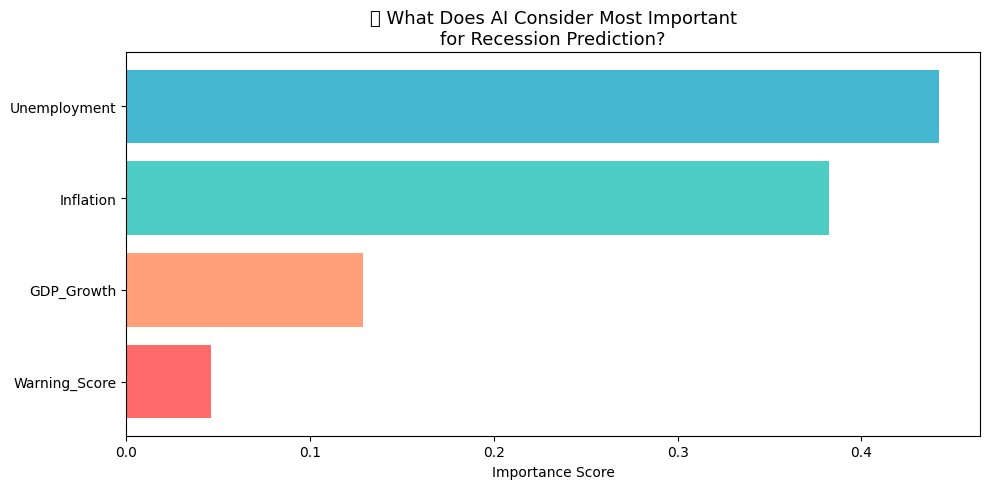

✅ Feature importance chart saved!


In [10]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'],
         color=['#FF6B6B', '#FFA07A', '#4ECDC4', '#45B7D1'])
plt.title('🧠 What Does AI Consider Most Important\nfor Recession Prediction?',
          fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance chart saved!")